# FIAP Tech Challenge Fase 1

Notebook corrigido e ampliado com mais modelos para comparação,
mantendo o fluxo clássico de EDA, treino, avaliação, SHAP e exportação.


In [1]:
# 1. Importando bibliotecas e carregando o dataset
import os
from pathlib import Path
import pandas as pd
from sklearn.datasets import load_breast_cancer

def find_project_root():
    start = Path.cwd()
    for candidate in [start] + list(start.parents):
        if (candidate / "src").exists() and (candidate / "models").exists():
            return candidate
    raise FileNotFoundError("Não foi possível localizar a raiz do projeto.")

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
print(f"📁 Projeto localizado em: {PROJECT_ROOT}")

datos = load_breast_cancer()
X = pd.DataFrame(datos.data, columns=datos.feature_names)
y = pd.Series(datos.target)

print("✅ Dados carregados com sucesso!")
print(f"Total de pacientes/amostras: {X.shape[0]}")
print(f"Total de características clínicas (colunas): {X.shape[1]}\n")
X.head()


📁 Projeto localizado em: C:\Users\ricoi\POSTECH\tech-challenge-fase1
✅ Dados carregados com sucesso!
Total de pacientes/amostras: 569
Total de características clínicas (colunas): 30



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [2]:
# 2. Verificação de qualidade dos dados
print("🔍 VERIFICANDO A QUALIDADE DOS DADOS...\n")
print(f"-> Total de valores nulos/faltantes na base: {X.isnull().sum().sum()}")
print(f"-> Total de linhas 100% duplicadas: {X.duplicated().sum()}")
print("\n📊 DISTRIBUIÇÃO DAS CLASSES (DIAGNÓSTICO):")
print(y.value_counts().rename(index={0: "Maligno (0)", 1: "Benigno (1)"}))


🔍 VERIFICANDO A QUALIDADE DOS DADOS...

-> Total de valores nulos/faltantes na base: 0
-> Total de linhas 100% duplicadas: 0

📊 DISTRIBUIÇÃO DAS CLASSES (DIAGNÓSTICO):
Benigno (1)    357
Maligno (0)    212
Name: count, dtype: int64


In [3]:
# 3. Split 80/20 estratificado + normalização
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Divisão e normalização concluídas com sucesso!")
print(f"-> Quantidade de dados de TREINO (80%): {X_train.shape[0]} pacientes")
print(f"-> Quantidade de dados de TESTE (20%): {X_test.shape[0]} pacientes")


✅ Divisão e normalização concluídas com sucesso!
-> Quantidade de dados de TREINO (80%): 455 pacientes
-> Quantidade de dados de TESTE (20%): 114 pacientes


In [4]:
# 4. Treinamento de 6 modelos para ampliar o range de comparação
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.base import clone
from pathlib import Path
import joblib

modelos = {
    "logistic_regression": LogisticRegression(max_iter=1000, random_state=42),
    "decision_tree": DecisionTreeClassifier(random_state=42, max_depth=6),
    "random_forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight="balanced"),
    "gradient_boosting": GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=42),
    "svm": SVC(probability=True, random_state=42),
    "knn": KNeighborsClassifier(n_neighbors=5),
}

resultados = []
modelos_treinados = {}

tabular_dir = PROJECT_ROOT / "models" / "tabular"
tabular_dir.mkdir(parents=True, exist_ok=True)

for nome, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)
    y_proba = modelo.predict_proba(X_test_scaled)[:, 1]

    metrics = {
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Sensibilidade (Recall)": recall_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba),
    }
    resultados.append(metrics)
    modelos_treinados[nome] = modelo

    joblib.dump(modelo, tabular_dir / f"{nome}.joblib")

joblib.dump(scaler, tabular_dir / "scaler.joblib")
joblib.dump(list(datos.feature_names), tabular_dir / "feature_names.joblib")

df_resultados = pd.DataFrame(resultados).sort_values("F1-Score", ascending=False).reset_index(drop=True)
print("🏆 TABELA COMPARATIVA DOS MODELOS (DADOS DE TESTE):\n")
df_resultados


C:\Users\ricoi\POSTECH\tech-challenge-fase1\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


🏆 TABELA COMPARATIVA DOS MODELOS (DADOS DE TESTE):



,Modelo,Acurácia,Sensibilidade (Recall),Precisão,F1-Score,AUC
0,logistic_regression,0.982456,0.986111,0.986111,0.986111,0.995370
1,svm,0.982456,0.986111,0.986111,0.986111,0.995040
2,knn,0.956140,0.972222,0.958904,0.965517,0.978836
3,random_forest,0.947368,0.944444,0.971429,0.957746,0.994378
4,gradient_boosting,0.938596,0.944444,0.957746,0.951049,0.986111
5,decision_tree,0.912281,0.902778,0.955882,0.928571,0.914683


C:\Users\ricoi\POSTECH\tech-challenge-fase1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🩺 ATRIBUTOS MAIS CRÍTICOS PARA O DIAGNÓSTICO MÉDICO (SHAP Summary Plot):



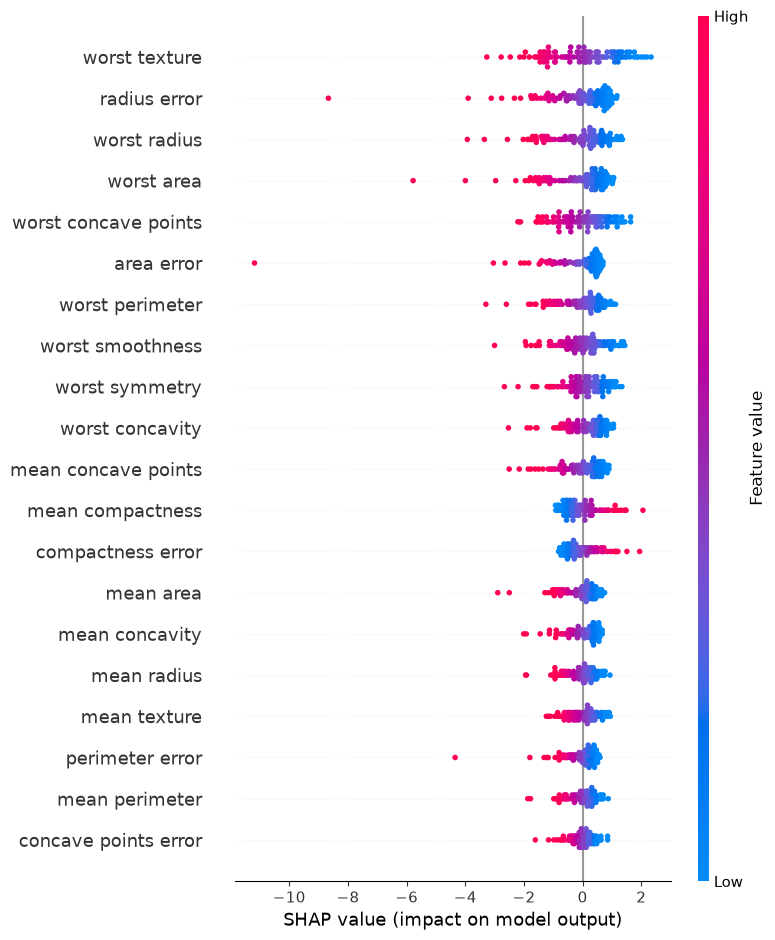

In [5]:
# 5. Explicabilidade SHAP usando o modelo de referência
try:
    import shap
    import matplotlib.pyplot as plt

    modelo_referencia = modelos_treinados["logistic_regression"]
    background = X_train_scaled[:100]
    explainer = shap.Explainer(modelo_referencia, background, feature_names=list(datos.feature_names))
    shap_values = explainer(X_test_scaled)

    print("🩺 ATRIBUTOS MAIS CRÍTICOS PARA O DIAGNÓSTICO MÉDICO (SHAP Summary Plot):\n")
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_scaled, feature_names=datos.feature_names, show=False)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"⚠️ SHAP não pôde ser executado neste ambiente: {e}")


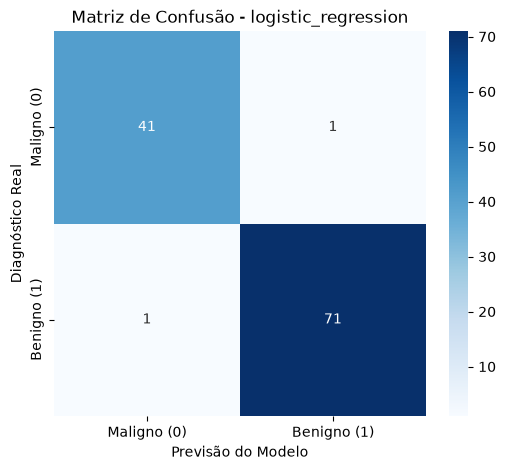

✅ Artefatos legados preservados sem sobrescrita.
✅ Artefatos salvos em C:\Users\ricoi\POSTECH\tech-challenge-fase1\models\tabular e C:\Users\ricoi\POSTECH\tech-challenge-fase1\models\legacy


In [6]:
# 6. Matriz de confusão e exportação dos artefatos
import seaborn as sns
from sklearn.metrics import confusion_matrix

best_model_name = df_resultados.iloc[0]["Modelo"]
melhor_modelo = modelos_treinados[best_model_name]
y_pred = melhor_modelo.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Maligno (0)", "Benigno (1)"],
            yticklabels=["Maligno (0)", "Benigno (1)"])
plt.title(f"Matriz de Confusão - {best_model_name}")
plt.xlabel("Previsão do Modelo")
plt.ylabel("Diagnóstico Real")
plt.show()

legacy_dir = PROJECT_ROOT / "models" / "legacy"
legacy_dir.mkdir(parents=True, exist_ok=True)
legacy_model_path = legacy_dir / "modelo_breast_cancer.pkl"
legacy_scaler_path = legacy_dir / "scaler.pkl"

if legacy_model_path.exists() and legacy_scaler_path.exists():
    print("✅ Artefatos legados preservados sem sobrescrita.")
else:
    joblib.dump(modelos_treinados["logistic_regression"], legacy_model_path)
    joblib.dump(scaler, legacy_scaler_path)
    print("⚠️ Legado não encontrado; fallback gerado com Logistic Regression.")

print(f"✅ Artefatos salvos em {tabular_dir} e {legacy_dir}")


## Próximo passo

Use estes artefatos para ampliar o catálogo da API tabular e manter a lógica igual nos demais modelos do projeto.
